<a href="https://colab.research.google.com/github/starlton/Deep-Learning/blob/main/Week%203/week3_logreg_math.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 3 — The Math of Logistic Regression

**Goal:** Derive and implement the three mathematical pieces that make logistic regression work, before assembling the full model.

1. **Sigmoid** — squashes any number into a probability between 0 and 1
2. **Binary cross-entropy loss** — measures how wrong a probabilistic prediction is
3. **The gradient** — which simplifies beautifully to `(p - y)`

Each piece is verified numerically against the gradient checker from Week 3, so nothing is taken on faith.

---

## Setup

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt

%matplotlib inline

---
## 1. The Sigmoid Function

Logistic regression needs to turn a raw score (the **logit** $z$, which can be any real number) into a probability between 0 and 1. The sigmoid does exactly this:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

- As $z \to +\infty$, $\sigma(z) \to 1$
- As $z \to -\infty$, $\sigma(z) \to 0$
- At $z = 0$, $\sigma(z) = 0.5$

This produces the characteristic S-curve.

In [2]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

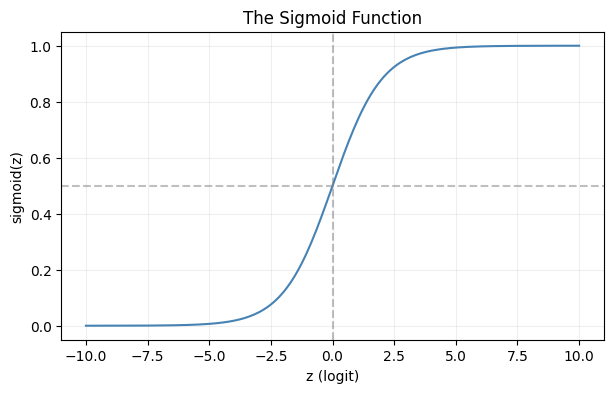

In [3]:
# Plot the S-curve over a fine range
zs = np.linspace(-10, 10, 200)

plt.figure(figsize=(7, 4))
plt.plot(zs, sigmoid(zs), color='steelblue')
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.title("The Sigmoid Function")
plt.xlabel("z (logit)")
plt.ylabel("sigmoid(z)")
plt.grid(alpha=0.2)
plt.show()

---
## 2. The Sigmoid Derivative

The derivative of the sigmoid has an elegant closed form expressed in terms of the sigmoid itself:

$$\sigma'(z) = \sigma(z)\,(1 - \sigma(z))$$

This means once you've computed $\sigma(z)$ during the forward pass, the derivative is almost free — just multiply it by $(1 - \sigma(z))$. (Same elegant property tanh had in micrograd.)

**Important:** the function below takes a raw logit $z$ and sigmoids it internally — so always pass the raw $z$, not an already-sigmoided value.

In [4]:
def deriv_sigmoid(z):
    s = sigmoid(z)          # sigmoid the raw logit first
    return s * (1 - s)      # then apply the derivative formula

In [5]:
# Check at z = 2: sigmoid(2) = 0.8808, derivative = 0.8808 * (1 - 0.8808)
print(f"sigmoid(2)       = {sigmoid(2):.6f}")
print(f"deriv_sigmoid(2) = {deriv_sigmoid(2):.6f}")

sigmoid(2)       = 0.880797
deriv_sigmoid(2) = 0.104994


### Verify numerically

Compare the analytical derivative to the symmetric-difference estimate from Week 3. If they agree, the formula is correct.

In [6]:
z = 2.0
h = 1e-6

analytical = deriv_sigmoid(z)
numerical = (sigmoid(z + h) - sigmoid(z - h)) / (2 * h)

print(f"analytical: {analytical:.6f}")
print(f"numerical:  {numerical:.6f}")
print(f"match: {np.isclose(analytical, numerical, atol=1e-4)}")

analytical: 0.104994
numerical:  0.104994
match: True


---
## 3. Binary Cross-Entropy Loss

Cross-entropy measures how far a predicted probability is from the true label. For binary classification (label $y \in \{0, 1\}$, prediction $p \in (0, 1)$):

$$L = -\big[\,y \log(p) + (1 - y)\log(1 - p)\,\big]$$

Only one term is ever active:
- If $y = 1$: $L = -\log(p)$ — penalizes a low predicted probability for the positive class
- If $y = 0$: $L = -\log(1 - p)$ — penalizes a high predicted probability

**The epsilon clip** is essential: if $p$ is ever exactly 0 or 1, $\log(0) = -\infty$ crashes. Clipping $p$ slightly away from the boundaries prevents this.

In [7]:
def bce(y_true, y_pred):
    epsilon = 1e-7
    # Clip the prediction away from exactly 0 or 1 to avoid log(0).
    y_pred = min(max(y_pred, epsilon), 1 - epsilon)
    return -(y_true * math.log(y_pred) + (1 - y_true) * math.log(1 - y_pred))

### Good prediction vs bad prediction

With the true label $y = 1$:
- A confident, correct prediction ($p = 0.9$) should give a small loss
- A confident, wrong prediction ($p = 0.1$) should give a large loss

In [8]:
print(f"y=1, p=0.9 (good): loss = {bce(1, 0.9):.4f}")
print(f"y=1, p=0.1 (bad):  loss = {bce(1, 0.1):.4f}")
print(f"\nThe bad prediction's loss is ~{bce(1, 0.1)/bce(1, 0.9):.0f}x larger.")

y=1, p=0.9 (good): loss = 0.1054
y=1, p=0.1 (bad):  loss = 2.3026

The bad prediction's loss is ~22x larger.


The bad prediction is punished about 22x harder, even though both probabilities are the same distance (0.1) from certainty. This is the defining property of cross-entropy: $-\log(p) \to \infty$ as $p \to 0$, so **confident wrong predictions are penalized severely**, producing a large corrective gradient.

---

## 4. The Gradient — Why It Simplifies to (p - y)

We want the gradient of the loss with respect to the **logit** $z$ (the raw score before sigmoid). Using the chain rule through $p = \sigma(z)$:

$$\frac{dL}{dz} = \frac{dL}{dp} \cdot \frac{dp}{dz}$$

**Piece 1** — derivative of the loss w.r.t. the prediction:
$$\frac{dL}{dp} = -\left[\frac{y}{p} - \frac{1-y}{1-p}\right]$$

**Piece 2** — the sigmoid derivative:
$$\frac{dp}{dz} = p(1-p)$$

**Multiply and distribute** the $p(1-p)$ into the bracket:
$$\frac{dL}{dz} = -\left[\frac{y}{p}\cdot p(1-p) - \frac{1-y}{1-p}\cdot p(1-p)\right] = -\big[\,y(1-p) - (1-y)p\,\big]$$

**Expand** inside the bracket:
$$= -\big[\,y - yp - p + yp\,\big]$$

The $yp$ terms cancel:
$$= -\big[\,y - p\,\big] = \boxed{p - y}$$

The messy combination of sigmoid and cross-entropy collapses to **prediction minus true label**. This is exactly why sigmoid and cross-entropy are always paired — their combined gradient is trivially simple, which makes training fast and stable.

### Verify the (p - y) gradient numerically

Compute $dL/dz$ two ways: the clean analytical form $(p - y)$, and the numerical symmetric difference applied to the full sigmoid-then-loss pipeline. They must match.

In [9]:
# Pick a logit and a true label
z = 0.7
y = 1.0

# Analytical gradient: just (p - y)
p = sigmoid(z)
analytical = p - y

# Numerical gradient: nudge z, measure how the full loss changes.
# loss_at chains sigmoid then bce, so this captures the whole dL/dz.
def loss_at(z_val):
    return bce(y, sigmoid(z_val))

h = 1e-6
numerical = (loss_at(z + h) - loss_at(z - h)) / (2 * h)

print(f"analytical (p - y): {analytical:.6f}")
print(f"numerical:          {numerical:.6f}")
print(f"match: {np.isclose(analytical, numerical, atol=1e-4)}")

analytical (p - y): -0.331812
numerical:          -0.331812
match: True


Both give the same value, confirming the derivation. Two completely independent methods — hand calculus and numerical estimation — agree, so the $(p - y)$ result is proven.

---

## Summary

| Piece | Formula | Verified |
|---|---|---|
| Sigmoid | $\sigma(z) = \dfrac{1}{1+e^{-z}}$ | S-curve plotted |
| Sigmoid derivative | $\sigma'(z) = \sigma(z)(1-\sigma(z))$ | numerically ✓ |
| Binary cross-entropy | $L = -[y\log p + (1-y)\log(1-p)]$ | good vs bad checked |
| Loss gradient | $\dfrac{dL}{dz} = p - y$ | numerically ✓ |

**The big takeaway:** the gradient of sigmoid + cross-entropy with respect to the logit is just `(p - y)`. This single clean expression is the engine of logistic regression.

**Next: assemble these pieces into a full LogisticRegression class and train it on the Titanic data.**